# MIPT Tutorial - Measurement-Induced Phase Transition

This tutorial demonstrates the **Measurement-Induced Phase Transition (MIPT)** in a 1D quantum circuit with random unitary gates and projective measurements.

## What is MIPT?

The MIPT arises from a competition between two processes:

1. **Unitary evolution** (Haar random gates): Creates entanglement between qubits
2. **Projective measurements** (Z-basis): Destroys entanglement locally

Depending on the measurement rate, the system exhibits two distinct phases:

- **Volume-law phase** (p < p_c ≈ 0.16): Entanglement entropy scales with system size S ~ L
- **Area-law phase** (p > p_c ≈ 0.16): Entanglement entropy remains constant S ~ const
- **Critical point** (p ≈ p_c): Logarithmic scaling S ~ log(L)


## Setup

First, activate the project environment and import QuantumCircuitsMPS:

In [1]:
using Pkg; Pkg.activate(dirname(@__DIR__))
using QuantumCircuitsMPS
using Printf
using Statistics
using Plots
using ProgressMeter
using Luxor

  Activating project at `~/personal/QuantumCircuitsMPS.jl`


## Section 1: Setup and Parameters

Define the system parameters for the MIPT simulation:

In [2]:
# Define system parameters
const L = 8                   # System size (number of qubits)
const bc = :open           # Boundary conditions
const n_steps = L             # Total timesteps for simulation (passed to simulate!(n_steps=n_steps))
const p = 0.5                 # Measurement probability (near critical p_c ≈ 0.16)
const cut = L ÷ 2              # Entanglement cut position

println("Parameters:")
println("  L = $L (system size)")
println("  bc = $bc (boundary conditions)")
println("  n_steps = $n_steps (circuit timesteps)")
println("  p = $p (measurement probability)")
println("  cut = $cut (entanglement cut position)")

Parameters:
  L = 8 (system size)
  bc = open (boundary conditions)
  n_steps = 8 (circuit timesteps)
  p = 0.5 (measurement probability)
  cut = 4 (entanglement cut position)


## Section 2: Building the MIPT Circuit

The circuit implements the standard MIPT protocol with Bricklayer unitary gates followed by stochastic measurements.


In [3]:
# Build circuit (one full MIPT cycle per do-block execution: even+measure+odd+measure)
circuit = Circuit(L=L, bc=bc, p=p) do c
    apply!(c, HaarRandom(), Bricklayer(:even))
    apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
        (probability=c.params[:p], gate=Measurement(:Z), geometry=AllSites())
    ])
    apply!(c, HaarRandom(), Bricklayer(:odd))
    apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
        (probability=c.params[:p], gate=Measurement(:Z), geometry=AllSites())
    ])
end

println("Circuit built successfully")
println("Circuit parameters: L=$(circuit.L), bc=$(circuit.bc)")
println("System size: $(circuit.L) qubits")
println("Boundary conditions: $(circuit.bc)")

Circuit built successfully
Circuit parameters: L=8, bc=open
System size: 8 qubits
Boundary conditions: open
Circuit parameters: L=8, bc=open
System size: 8 qubits
Boundary conditions: open


### Circuit Visualization

Visualize the circuit structure to inspect the gate layout before running the simulation:

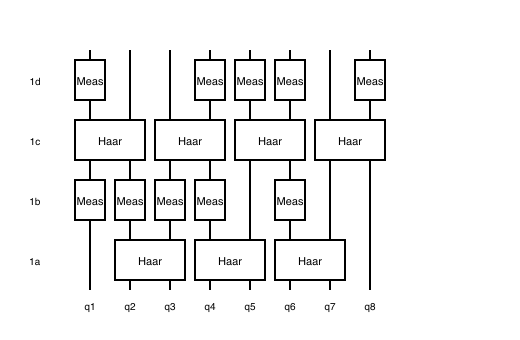

In [6]:
plot_circuit(circuit; gates_spacetime=0)

## Section 3: Simulation with Entanglement Tracking

We track the **entanglement entropy** at the central cut (position L÷2) to monitor the competition between:
- Unitary entanglement generation
- Measurement-induced disentanglement

The `EntanglementEntropy` observable computes the von Neumann entropy across a bipartite cut:

$$S = -\sum_i \lambda_i^2 \log(\lambda_i^2)$$

where $\lambda_i$ are the Schmidt coefficients from the SVD of the MPS bond.

In [7]:
# Create simulation state with RNG registry
state = SimulationState(
    L=L,
    bc=bc,
    rng=RNGRegistry(gates_spacetime=0, born_measurement=0, gates_realization=2)
)

# Initialize to product state |0⟩⊗L
initialize!(state, ProductState(binary_int=0))

# Track entanglement entropy at the central cut
track!(state, :entropy => EntanglementEntropy(; cut=cut))

# Run simulation: execute circuit n_steps times (n_steps=n_steps)
simulate!(circuit, state; n_steps=n_steps, record_when=:every_step)

# Extract entropy values from state
entropy_vals = state.observables[:entropy]

println("✓ Simulation complete")
println("  Recorded $(length(entropy_vals)) entropy values")
println()

✓ Simulation complete
  Recorded 8 entropy values

  Recorded 8 entropy values



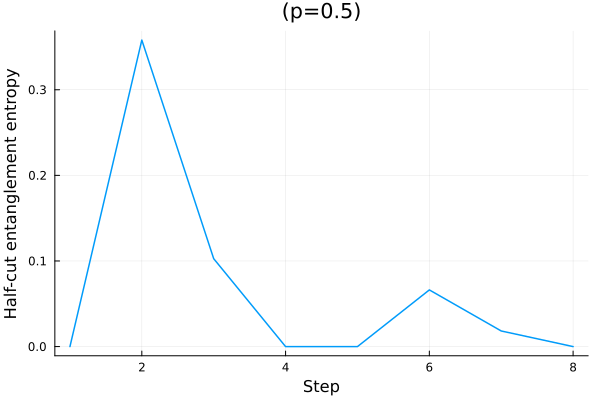

In [8]:
plot(entropy_vals, xlabel="Step", ylabel="Half-cut entanglement entropy", title="(p=$p)",
     legend=false, lw=1.5)

## Section 4: Steady-State Entanglement Entropy

Sweep `p` to compute the half-cut entanglement entropy as a function of measurement probability for multiple system sizes.

Each point is averaged over `ensemble_size` random seeds.

In [9]:
function run_mipt(; L, p, seed, bc=:open, n_steps=L, maxdim=1024)
    circuit = Circuit(L=L, bc=bc, p=p) do c
        apply!(c, HaarRandom(), Bricklayer(:even))
        apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
            (probability=c.params[:p], gate=Measurement(:Z), geometry=AllSites())
        ])
        apply!(c, HaarRandom(), Bricklayer(:odd))
        apply_with_prob!(c; rng=:gates_spacetime, outcomes=[
            (probability=c.params[:p], gate=Measurement(:Z), geometry=AllSites())
        ])
    end

    state = SimulationState(L=L, bc=bc, maxdim=maxdim,cutoff = 1e-6,
        rng=RNGRegistry(gates_spacetime=seed, born_measurement=seed+100, gates_realization=seed+200))
    initialize!(state, ProductState(binary_int=0))
    track!(state, :entropy => EntanglementEntropy(; cut=L÷2))

    simulate!(circuit, state; n_steps=n_steps, record_when=:final_only)
    return state.observables[:entropy][end]
end

run_mipt (generic function with 1 method)

In [10]:
# Sweep parameters
L_list = [4, 6, 8]
p_list = 0.1:0.1:0.9 |> collect
ensemble_size = 500

configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:ensemble_size]
raw = Vector{Float64}(undef, length(configs))

# Run with `julia -t auto` for multithreaded execution
println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_mipt(L=c.L, p=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = ensemble_size, length(p_list), length(L_list)
S_raw = reshape(raw, ns, np, nL)
S_mean = dropdims(mean(S_raw, dims=1), dims=1)
S_sem  = dropdims(std(S_raw, dims=1), dims=1) ./ sqrt(size(S_raw, 1))

println("Done!")

Running 13500 configs on 6 threads...


Progress: 100%|█████████████████████████████████████████| Time: 0:05:18


319.022250 seconds (3.90 G allocations: 790.652 GiB, 19.14% gc time, 372 lock conflicts, 1.66% compilation time)
Done!



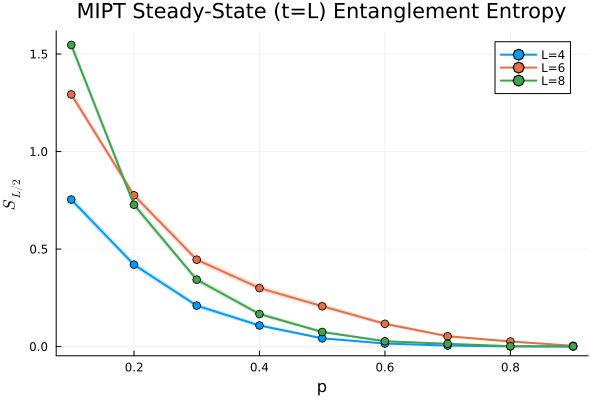

In [11]:
p_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$", title=raw"MIPT Steady-State (t=L) Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, S_mean[:, iL], ribbon=S_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4)
end
p_fig

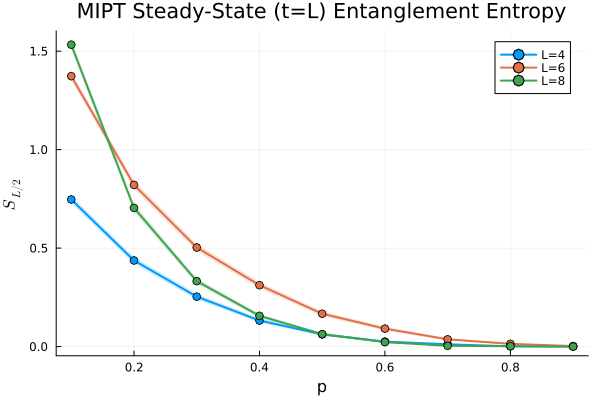

In [ ]:
p_fig = plot(xlabel="p", ylabel=raw"$S_{L/2}$", title=raw"MIPT Steady-State (t=L) Entanglement Entropy", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(p_fig, p_list, S_mean[:, iL], ribbon=S_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4)
end
p_fig